In [1]:
%matplotlib inline
import torch
from torch.utils.data import Dataset
import tensorflow as tf
import numpy as np
import os
import matplotlib.pyplot as plt
import cv2

from waymo_open_dataset.protos import end_to_end_driving_data_pb2 as wod_e2ed_pb2
from waymo_open_dataset import dataset_pb2 as open_dataset
from waymo_open_dataset.wdl_limited.camera.ops import py_camera_model_ops
from waymo_open_dataset.protos import end_to_end_driving_data_pb2 as wod_e2ed_pb2
from waymo_open_dataset.protos import end_to_end_driving_submission_pb2 as wod_e2ed_submission_pb2

2026-05-22 10:08:51.678981: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-22 10:08:51.728473: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-22 10:08:51.995737: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-22 10:08:54.138729: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
class WaymoE2EDataset(Dataset):
    def __init__(self, tfrecord_files, transform=None, cache_size=5000):
        self.filenames = tf.io.matching_files(tfrecord_files)
        self.transform = transform
        self.cache_size = cache_size

        self.file_lengths = []
        self.cumulative_lengths = []
        self.file_caches = [{} for _ in self.filenames]

        cum_len = 0
        for f_idx, f in enumerate(self.filenames):
            dataset = tf.data.TFRecordDataset(f)
            length = sum(1 for _ in dataset)
            self.file_lengths.append(length)
            cum_len += length
            self.cumulative_lengths.append(cum_len)

    def __len__(self):
        return self.cumulative_lengths[-1]
    
    def _get_file_and_index(self, idx):
        file_idx = np.searchsorted(self.cumulative_lengths, idx)
        if file_idx == 0:
            example_idx = idx
        else:
            example_idx = idx - self.cumulative_lengths[file_idx - 1]
        return file_idx, example_idx
    
    def __getitem__(self, idx):
        file_idx, example_idx = self._get_file_and_index(idx)

        cache = self.file_caches[file_idx]
        if example_idx in cache:
            bytes_example = cache[example_idx]
        else:
            dataset = tf.data.TFRecordDataset(self.filenames[file_idx])
            for i, raw in enumerate(dataset):
                if i == example_idx:
                    bytes_example = raw.numpy()
                    break
            
            if len(cache) >= self.cache_size:
                first_key = next(iter(cache))
                del cache[first_key]

            cache[example_idx] = bytes_example

        data = wod_e2ed_pb2.E2EDFrame()
        data.ParseFromString(bytes_example)
    
        image_list, calibration = self.return_front3_cameras(data)
        if image_list is None:
            raise ValueError("No front camera image found")
        
        image = np.concatenate(image_list, axis=1)

        if self.transform:
            image = self.transform(image)

        waypoints_3d = np.stack([
            data.future_states.pos_x,
            data.future_states.pos_y,
            data.future_states.pos_z
        ], axis=1).astype(np.float32)

        waypoints_2d = np.stack([
            data.future_states.pos_x,
            data.future_states.pos_y,
        ], axis=1).astype(np.float32)

        pose = data.frame.images[0].pose

        return image_list, calibration, waypoints_3d, pose # Uncomment this when visualizing data

        # return image, waypoints_2d # Comment this line out if you want to visualize the data

    def return_center_camera(self, data: wod_e2ed_pb2.E2EDFrame):
        for index, image_content in enumerate(data.frame.images):
            if image_content.name == 1:
                image = tf.io.decode_image(image_content.image).numpy()
                return image
        return None

    def return_front3_cameras(self, data:wod_e2ed_pb2.E2EDFrame):
        image_list = []
        calibration_list = []
        order = [2, 1, 3]
        for camera_name in order:
            for index, image_content in enumerate(data.frame.images):
                if image_content.name == camera_name:
                    calibration = data.frame.context.camera_calibrations[index]
                    image = tf.io.decode_image(image_content.image).numpy()
                    image_list.append(image)
                    calibration_list.append(calibration)
                    break
        
        return image_list, calibration_list

In [8]:
DATASET_FOLDER = 'waymo_open_dataset'

TRAIN_FILES = os.path.join(DATASET_FOLDER, 'training_*.tfrecord*')
VALIDATION_FILES = os.path.join(DATASET_FOLDER, 'val_*.tfrecord*')
TEST_FILES = os.path.join(DATASET_FOLDER, 'test_*.tfrecord*')

print(TRAIN_FILES)

data = WaymoE2EDataset(TRAIN_FILES)
img, c, w, p = data.__getitem__(100) # Uncomment for visualization
print(data.__len__())

waymo_open_dataset/training_*.tfrecord*
1597


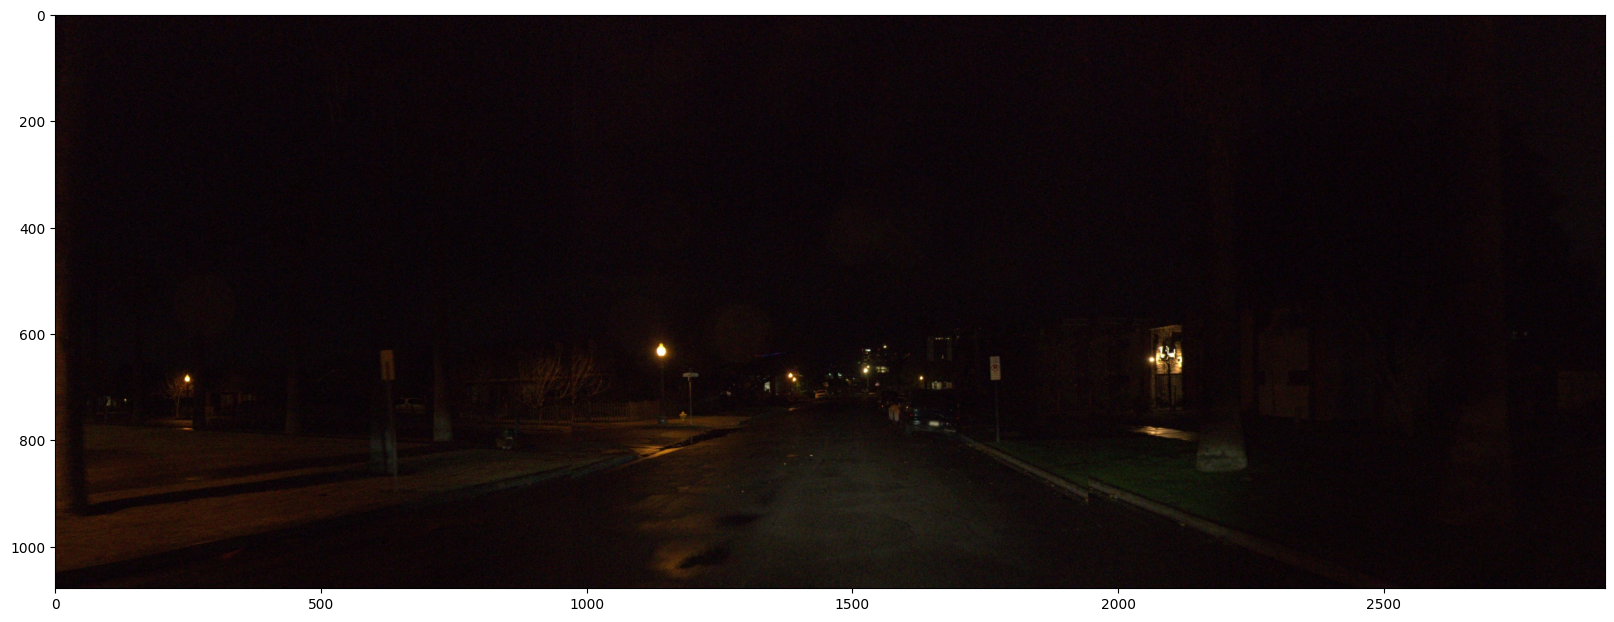

In [9]:
combined_image = np.concatenate(img, axis=1)
plt.figure(figsize=(20, 20))
plt.imshow(combined_image)

[[ 2.3369141e+00 -5.8593750e-03  7.2021484e-03]
 [ 4.5996094e+00 -2.3437500e-02  1.4556885e-02]
 [ 6.7700195e+00 -4.4921875e-02  2.2216797e-02]
 [ 8.8603516e+00 -7.0312500e-02  2.1118164e-02]
 [ 1.0875000e+01 -9.7656250e-02  3.3294678e-02]
 [ 1.2828613e+01 -1.2695312e-01  3.4881592e-02]
 [ 1.4759277e+01 -1.6015625e-01  3.6132812e-02]
 [ 1.6680176e+01 -1.9726562e-01  4.2327881e-02]
 [ 1.8575684e+01 -2.3632812e-01  4.1412354e-02]
 [ 2.0481934e+01 -2.7734375e-01  4.3304443e-02]
 [ 2.2409180e+01 -3.2031250e-01  5.0720215e-02]
 [ 2.4358887e+01 -3.6328125e-01  5.5328369e-02]
 [ 2.6329102e+01 -4.0820312e-01  6.8878174e-02]
 [ 2.8324707e+01 -4.5312500e-01  7.0526123e-02]
 [ 3.0349121e+01 -4.9804688e-01  6.2622070e-02]
 [ 3.2395508e+01 -5.4492188e-01  6.5979004e-02]
 [ 3.4449707e+01 -5.9179688e-01  9.9273682e-02]
 [ 3.6539062e+01 -6.4257812e-01  8.8287354e-02]
 [ 3.8645020e+01 -6.9531250e-01  1.0067749e-01]
 [ 4.0773438e+01 -7.4804688e-01  1.0873413e-01]]


Text(0.5, 1.0, 'Future trajectory')

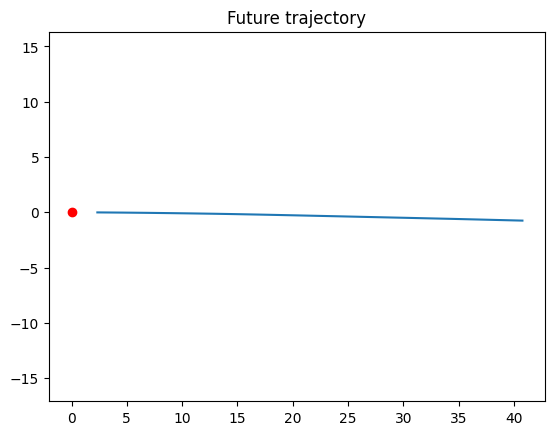

In [10]:
print(w)
plt.figure()
plt.plot(w[:,0], w[:,1])
plt.scatter(0,0,c="red")
plt.axis("equal")
plt.title("Future trajectory")

In [11]:
# Helper function given by waymo
def project_vehicle_to_image(vehicle_pose, calibration, points):
  """Projects from vehicle coordinate system to image with global shutter.

  Arguments:
    vehicle_pose: Vehicle pose transform from vehicle into world coordinate
      system.
    calibration: Camera calibration details (including intrinsics/extrinsics).
    points: Points to project of shape [N, 3] in vehicle coordinate system.

  Returns:
    Array of shape [N, 3], with the latter dimension composed of (u, v, ok).
  """
  # Transform points from vehicle to world coordinate system (can be
  # vectorized).
  pose_matrix = np.array(vehicle_pose.transform).reshape(4, 4)
  world_points = np.zeros_like(points)
  for i, point in enumerate(points):
    cx, cy, cz, _ = np.matmul(pose_matrix, [*point, 1])
    world_points[i] = (cx, cy, cz)

  # Populate camera image metadata. Velocity and latency stats are filled with
  # zeroes.
  extrinsic = tf.reshape(
      tf.constant(list(calibration.extrinsic.transform), dtype=tf.float32),
      [4, 4])
  intrinsic = tf.constant(list(calibration.intrinsic), dtype=tf.float32)
  metadata = tf.constant([
      calibration.width,
      calibration.height,
      open_dataset.CameraCalibration.GLOBAL_SHUTTER,
  ],
                         dtype=tf.int32)
  camera_image_metadata = list(vehicle_pose.transform) + [0.0] * 10

  # Perform projection and return projected image coordinates (u, v, ok).
  return py_camera_model_ops.world_to_image(extrinsic, intrinsic, metadata,
                                            camera_image_metadata,
                                            world_points).numpy()

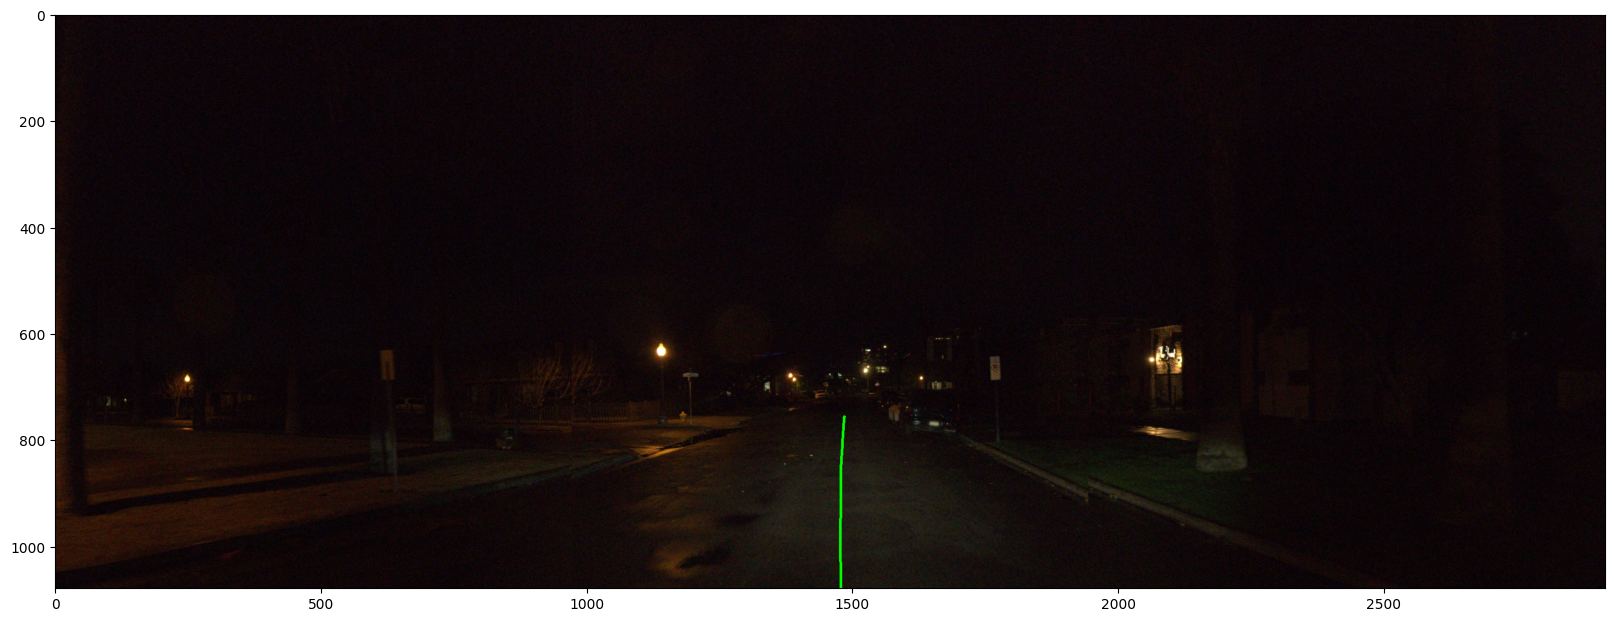

In [12]:
images_with_lines = []

for i in range(len(c)):
    waypoints_img = project_vehicle_to_image(p, c[i], w)
    
    im = img[i].copy()

    valid_points = []
    for u, v, ok in waypoints_img:
        if ok:
            valid_points.append((int(u), int(v)))
    
    for j in range(len(valid_points)-1):
        cv2.line(im, valid_points[j], valid_points[j+1], (0, 255, 0), 4)

    images_with_lines.append(im)

concat_img = np.concatenate(images_with_lines, axis=1)

plt.figure(figsize=(20, 20))
plt.imshow(concat_img)

In [3]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision.models as models
import torchvision.transforms as transforms

class DrivingModel(nn.Module):
    def __init__(self, num_waypoints=20):
        super().__init__()
        
        self.num_waypoints = num_waypoints

        self.backbone = models.resnet18(weights="IMAGENET1K_V1")

        self.backbone.fc = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, num_waypoints * 2)
        )

    def forward(self, x):
        x = self.backbone(x)

        x = x.view(-1, self.num_waypoints, 2)

        return x

In [9]:
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

model = DrivingModel(num_waypoints=20).to(device)

loss_fn = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

train_dataset = WaymoE2EDataset(TRAIN_FILES, transform)
val_dataset = WaymoE2EDataset(VALIDATION_FILES, transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=8,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=8,
    pin_memory=True,
    persistent_workers=True
)

num_epochs = 10

In [10]:
def train(num_epochs=10):
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0

        for images, waypoints in train_loader:
            images = images.float().to(device)
            waypoints = waypoints.float().to(device)

            preds = model(images)

            loss = loss_fn(preds, waypoints)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        
        print(f"Epoch {epoch + 1}/{num_epochs} | Train Loss: {avg_loss:.5f}")

In [ ]:
train()

In [ ]:
def validation():
    model.eval()

    val_loss = 0

    with torch.no_grad():
        for images, waypoints in val_loader:
            images = images.float().to(device)
            waypoints = waypoints.float().to(device)

            preds = model(images)

            loss = loss_fn(preds, waypoints)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    print("Validation Loss: ", val_loss)

In [9]:
validation()

Validation Loss:  55.11072980033027


In [10]:
torch.save(model.state_dict(), 'waymo_model.pth')
print("Model Saved!")

Model Saved!
